# Setup

In [68]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
#from pmdarima.arima.utils import ndiffs
import seaborn as sns


# Read the Data

In [23]:
folder_path = '../data/extracted_signals/'
data = []
file_name = []
for filename in glob.glob(os.path.join(folder_path, '*.npy')):
    with open(filename, 'r') as f:
        data.append(np.load(filename))
        file_name.append(filename)
#data = np.load("../data/extracted_signals/220516_No contraction videos.npy")
print(f'Nr of files: {len(data)}')

Nr of files: 15


In [24]:
idx_weak = []
idx_strong = []
idx_no= []
for n, file in enumerate(file_name):
    if "Weak" in file:
        print("weak", file)
        idx_weak.append(n)
    elif "Strong" in file:
        print("strong", file)
        idx_strong.append(n)
    else:
        print("no", file)
        idx_no.append(n)

weak ../data/extracted_signals/Weak contraction.lif - O1443_1b.npy
no ../data/extracted_signals/220516_No contraction videos.lif - O1319_3a.npy
no ../data/extracted_signals/220516_No contraction videos.lif - O1445_2a.npy
weak ../data/extracted_signals/Weak contraction.lif - O1318_1b.npy
strong ../data/extracted_signals/Strong contraction.lif - O1466_2a.npy
no ../data/extracted_signals/220516_No contraction videos.lif - O1463_1b.npy
strong ../data/extracted_signals/Strong contraction.lif - O1468_1b.npy
strong ../data/extracted_signals/Strong contraction.lif - O1319_1a.npy
no ../data/extracted_signals/220516_No contraction videos.lif - O1450_2 curare II.npy
weak ../data/extracted_signals/Weak contraction.lif - O1318_2a.npy
no ../data/extracted_signals/220516_No contraction videos.lif - O1498_1a curare.npy
strong ../data/extracted_signals/Strong contraction.lif - O1464_2a.npy
weak ../data/extracted_signals/Weak contraction.lif - O1301_3a.npy
strong ../data/extracted_signals/Strong contrac

In [25]:
data_weak = [data[i] for i in idx_weak]
data_strong = [data[i] for i in idx_strong]
data_no = [data[i] for i in idx_no]

# Example

In [55]:
ts = data_strong[0][0]
ts.shape

(1208,)

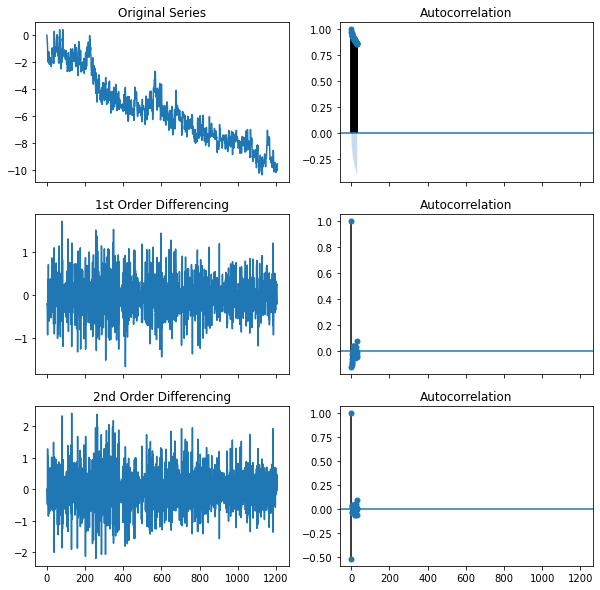

In [56]:
# Original Series
fig, axes = plt.subplots(3, 2, sharex=True, figsize=(10,10))
axes[0, 0].plot(ts); axes[0, 0].set_title('Original Series')
plot_acf(ts, ax=axes[0, 1])

# 1st Differencing
axes[1, 0].plot(np.diff(ts)); axes[1, 0].set_title('1st Order Differencing')
plot_acf(np.diff(ts), ax=axes[1, 1])

# 2nd Differencing
axes[2, 0].plot(np.diff(np.diff(ts))); axes[2, 0].set_title('2nd Order Differencing')
plot_acf(np.diff(np.diff(ts)), ax=axes[2, 1])

plt.show()

In [57]:
diff1 = np.diff(ts)
result = adfuller(diff1, autolag='AIC')
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')
for key, value in result[4].items():
    print('Critial Values:')
    print(f'   {key}, {value}')

ADF Statistic: -15.597812514134342
p-value: 1.8453625835298442e-28
Critial Values:
   1%, -3.435829423619109
Critial Values:
   5%, -2.863959622178626
Critial Values:
   10%, -2.5680582513898056


* p<0.05, Null hypothesis rejected. Time series is stationary

In [58]:
diff1.shape

(1207,)

In [59]:
n=20
diff1 = np.convolve(diff1, np.ones(n)/n, mode='valid')

In [60]:
# window function for fft
hann_s = np.hanning(diff1.shape[0])
# multiply window function with time series
signal_hann = diff1*hann_s

In [61]:
y_hann = np.fft.fft(signal_hann)

In [62]:
# convert to period
N = int(diff1.shape[0]/2) + 1
fa = 1
X = np.linspace(0, fa/2, N, endpoint=True)
Xp = 1.0/X 


<ipython-input-62-ad84adbc93e7>:5: RuntimeWarning: divide by zero encountered in true_divide
  Xp = 1.0/X


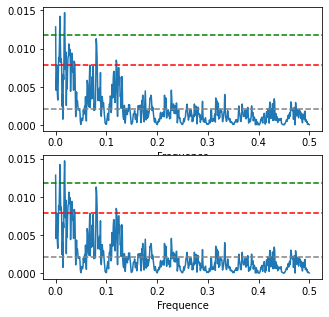

In [63]:
# fft
N = int(diff1.shape[0]/2) + 1
fig, axis = plt.subplots(2, 1, figsize=(5,5))
for i, ax in enumerate(axis):
    ts = 2.0*np.abs(y_hann[:N])/N
    ax.plot(X, ts)
    #plt.xticks([12, 24, 33, 84, 168])
    ax.set_xlabel('Frequence')
    mean = np.mean(ts)
    std = np.std(ts)
    per = np.percentile(ts, 95)
    axis[i].axhline(y=mean, color='grey', linestyle='--')
    axis[i].axhline(y=5*std, color='g', linestyle='--')
    axis[i].axhline(y=per, color='r', linestyle='--')

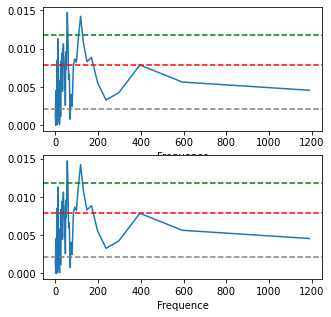

In [64]:
# fft
N = int(diff1.shape[0]/2) + 1
fig, axis = plt.subplots(2, 1, figsize=(5,5))
for i, ax in enumerate(axis):
    ts = 2.0*np.abs(y_hann[:N])/N
    ax.plot(Xp, ts)
    #plt.xticks([12, 24, 33, 84, 168])
    ax.set_xlabel('Frequence')
    mean = np.mean(ts)
    std = np.std(ts)
    per = np.percentile(ts, 95)
    axis[i].axhline(y=mean, color='grey', linestyle='--')
    axis[i].axhline(y=5*std, color='g', linestyle='--')
    axis[i].axhline(y=per, color='r', linestyle='--')

# Boxplots

In [18]:
df = pd.DataFrame()
for i in range(len(data_strong[0])):
    df[f'vid{i}'] = data_strong[0][i]
df

,vid0,vid1,vid2,vid3,vid4,vid5,vid6,vid7,vid8,vid9
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,-0.202151,-0.055419,-0.418242,-0.245357,-0.250794,-0.385965,-0.272727,-0.548103,-0.324060,-0.085684
2,-0.405556,-0.178571,-0.662757,-0.548387,-0.609319,-0.568627,-0.661779,-0.644444,-0.649477,-0.206897
3,-0.619608,-0.155530,-0.901001,-0.610887,-0.659722,-0.780702,-0.742424,-0.718835,-0.747619,-0.176594
4,-1.054545,-0.430672,-1.002151,-0.639296,-0.888889,-0.858333,-0.787879,-0.739899,-0.815873,-0.909599
...,...,...,...,...,...,...,...,...,...,...
1203,-9.678431,-8.910173,-9.029234,-8.483871,-8.192810,-7.892157,-7.404586,-6.884921,-6.576984,-6.206897
1204,-9.818391,-9.138393,-8.971198,-8.602441,-8.166667,-7.777778,-7.356710,-6.451201,-6.354762,-6.250375
1205,-10.025287,-9.440476,-9.387097,-8.805530,-8.376068,-7.894309,-7.385281,-6.644444,-6.666165,-6.873563
1206,-9.766667,-9.413594,-9.435484,-8.870968,-8.486928,-8.009804,-7.624777,-6.745726,-6.666165,-6.525078


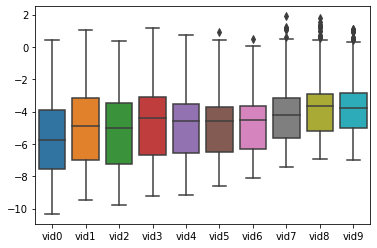

In [19]:
sns.boxplot(data=df);

In [20]:
df = pd.DataFrame()
for i in range(len(data_weak[0])):
    df[f'vid{i}'] = data_weak[0][i]
df

,vid0,vid1,vid2,vid3,vid4,vid5,vid6,vid7,vid8,vid9
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,-0.016667,-0.029915,0.000000,-0.041667,-0.083333,0.013333,0.000000,-0.040000,-0.041538,-0.029231
2,-0.016667,-0.076923,-0.080000,-0.041667,-0.083333,0.000000,0.000000,0.020000,-0.041538,0.170769
3,0.182609,0.192308,0.336667,0.076667,0.393333,0.520000,0.000000,0.212308,0.160000,0.423077
4,0.182609,0.155271,0.420000,0.083333,0.371795,0.721667,0.000000,0.360000,0.253333,0.490769
...,...,...,...,...,...,...,...,...,...,...
1504,3.955556,4.232308,4.211667,4.000000,4.393333,4.305000,4.000000,4.000000,3.760000,4.090769
1505,3.823077,4.192308,4.128333,4.000000,4.353333,4.305000,4.000000,4.000000,3.760000,4.090769
1506,3.935714,4.192308,4.128333,4.000000,4.353333,4.305000,4.000000,3.960000,3.880000,4.090769
1507,3.935714,4.192308,4.120000,3.958333,4.193333,4.200000,3.958333,3.936667,3.760000,4.090769


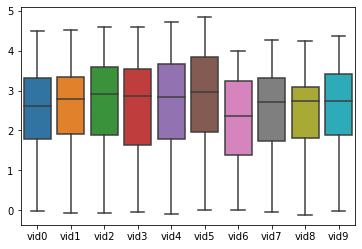

In [21]:
sns.boxplot(data=df);